# CSCI E-89 Assignment 03: Building an Image Classifier with PyTorch
**Author:** Levente Papp

This notebook wraps the code generated with Claude Code in Problem 1. It
follows the "Building an Image Classifier with PyTorch" section of
`10_neural_nets_with_pytorch.ipynb` and trains an MLP on Fashion MNIST.

Each code cell is one script from the `prob1/` folder of the repository,
in executable order. The Markdown cell above each code cell names its script.

**Before running:**
- Open this notebook from the **repository root** (next to the `prob1/`
  folder). The cells use paths like `prob1/outputs/`.
- Install the requirements: `pip install torch torchvision torchmetrics matplotlib numpy`
- Run the cells top to bottom (**Kernel → Restart & Run All**). Each cell
  uses names defined by the cells before it.

## Step 1: Setup
**Script:** `prob1/01_setup.py`

Imports, random seed (42), and device selection (CUDA, MPS, or CPU).

In [1]:
"""
CSCI E-89 Assignment 03, Problem 1 -- Step 1: Setup
Author: Levente Papp

Building an Image Classifier with PyTorch (Fashion MNIST).
This step handles imports, reproducibility (random seed), and device selection.

Notebook cell 1. Run the cells in order (1-8) from a notebook in the
repo root; each cell uses names defined by the earlier cells.
"""

import json
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchmetrics
import torchvision
import torchvision.transforms.v2 as T
from torch.utils.data import DataLoader

SEED = 42


def set_seed(seed=SEED):
    """Seed Python, NumPy, and PyTorch RNGs for reproducible results."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def get_device():
    """Pick the best available device: CUDA, then Apple MPS, then CPU."""
    if torch.cuda.is_available():
        return "cuda"
    elif torch.backends.mps.is_available():
        return "mps"
    else:
        return "cpu"


set_seed()
device = get_device()

print(f"PyTorch version:      {torch.__version__}")
print(f"TorchVision version:  {torchvision.__version__}")
print(f"TorchMetrics version: {torchmetrics.__version__}")
print(f"NumPy version:        {np.__version__}")
print(f"Matplotlib version:   {plt.matplotlib.__version__}")
print(f"Random seed:          {SEED}")
print(f"Device:               {device}")

PyTorch version:      2.14.0+cu130
TorchVision version:  0.29.0+cu130
TorchMetrics version: 1.9.0
NumPy version:        2.4.6
Matplotlib version:   3.11.2
Random seed:          42
Device:               cpu


## Step 2: Load the data
**Script:** `prob1/02_load_data.py`

Downloads Fashion MNIST, scales pixels to [0, 1], splits the 60,000 training images into 55,000 training / 5,000 validation, and builds DataLoaders with batch size 32.

In [2]:
"""
CSCI E-89 Assignment 03, Problem 1 -- Step 2: Load the data
Author: Levente Papp

Downloads Fashion MNIST, converts images to float tensors in [0, 1],
splits the 60,000 training images into 55,000 train / 5,000 validation,
and wraps everything in DataLoaders with batch size 32.

Notebook cell 2. Run the cells in order (1-8) from a notebook in the
repo root; each cell uses names defined by the earlier cells.
"""

DATA_DIR = Path("datasets")
BATCH_SIZE = 32

# ToImage() -> tensor of shape [C, H, W]; ToDtype(..., scale=True) -> float32 in [0, 1]
toTensor = T.Compose([T.ToImage(), T.ToDtype(torch.float32, scale=True)])

train_and_valid_data = torchvision.datasets.FashionMNIST(
    root=DATA_DIR, train=True, download=True, transform=toTensor)
test_data = torchvision.datasets.FashionMNIST(
    root=DATA_DIR, train=False, download=True, transform=toTensor)

torch.manual_seed(SEED)
train_data, valid_data = torch.utils.data.random_split(
    train_and_valid_data, [55_000, 5_000])

torch.manual_seed(SEED)
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_data, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE)

print(f"Training set:   {len(train_data):,} images")
print(f"Validation set: {len(valid_data):,} images")
print(f"Test set:       {len(test_data):,} images")
print(f"Classes:        {train_and_valid_data.classes}")

X_batch, y_batch = next(iter(train_loader))
print(f"Batch images shape: {tuple(X_batch.shape)}  dtype: {X_batch.dtype}")
print(f"Batch labels shape: {tuple(y_batch.shape)}  dtype: {y_batch.dtype}")
print(f"Pixel value range:  [{X_batch.min():.1f}, {X_batch.max():.1f}]")

Training set:   55,000 images
Validation set: 5,000 images
Test set:       10,000 images
Classes:        ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
Batch images shape: (32, 1, 28, 28)  dtype: torch.float32
Batch labels shape: (32,)  dtype: torch.int64
Pixel value range:  [0.0, 1.0]


## Step 3: Show sample images
**Script:** `prob1/03_show_samples.py`

A 4×8 grid of training images labeled with their class names.

Saved 32 sample images to prob1/figures/samples.png


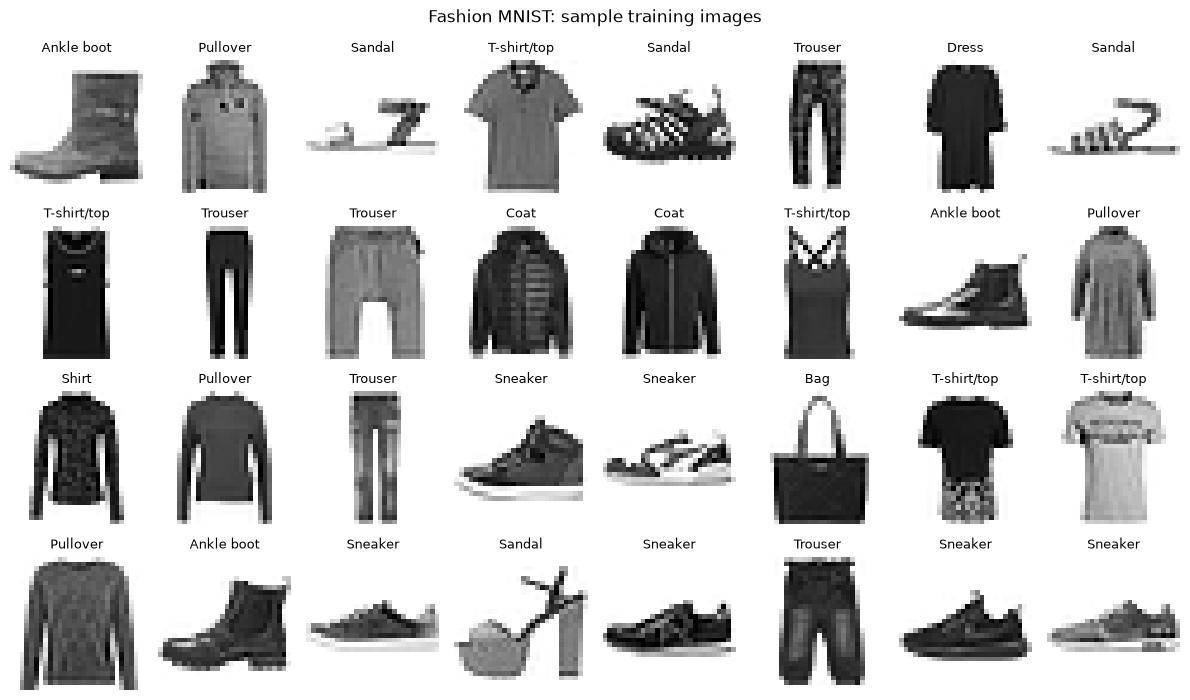

In [3]:
"""
CSCI E-89 Assignment 03, Problem 1 -- Step 3: Show sample images
Author: Levente Papp

Displays a grid of sample training images labeled with their class names.
The figure is saved to prob1/figures/samples.png and also shown.

Notebook cell 3. Run the cells in order (1-8) from a notebook in the
repo root; each cell uses names defined by the earlier cells.
"""

N_ROWS, N_COLS = 4, 8
FIG_PATH = Path("prob1/figures/samples.png")

class_names = train_and_valid_data.classes

fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(N_COLS * 1.5, N_ROWS * 1.8))
for i, ax in enumerate(axes.flat):
    image, label = train_data[i]
    # image has shape [1, 28, 28]; drop the channel dim for imshow
    ax.imshow(image.squeeze(0), cmap="binary")
    ax.set_title(class_names[label], fontsize=9)
    ax.axis("off")
fig.suptitle("Fashion MNIST: sample training images")
fig.tight_layout()

FIG_PATH.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(FIG_PATH, dpi=100)
print(f"Saved {N_ROWS * N_COLS} sample images to {FIG_PATH}")

# plt.show() only has an effect with an interactive backend (not on a headless machine)
if plt.get_backend().lower() != "agg":
    plt.show()

## Step 4: Training helpers
**Script:** `prob1/04_helpers.py`

`evaluate_tm()` computes a torchmetrics metric over a DataLoader; `train()` trains for n epochs and records training loss, training accuracy, and validation accuracy per epoch. Ends with a quick smoke test on a small subset.

In [4]:
"""
CSCI E-89 Assignment 03, Problem 1 -- Step 4: Training helpers
Author: Levente Papp

evaluate_tm(): computes a torchmetrics metric over a whole DataLoader.
train():       trains a model for n epochs, recording the training loss,
               training metric, and validation metric for each epoch.

The end of the cell does a quick smoke test on a small data subset.

Notebook cell 4. Run the cells in order (1-8) from a notebook in the
repo root; each cell uses names defined by the earlier cells.
"""


def evaluate_tm(model, data_loader, metric):
    """Return metric computed over every batch in data_loader."""
    model.eval()
    metric.reset()  # clear state left over from any previous use
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            metric.update(y_pred, y_batch)  # accumulate batch statistics
    return metric.compute()  # aggregate over the whole dataset


def train(model, optimizer, criterion, metric, train_loader, valid_loader,
          n_epochs):
    """Train for n_epochs and return a history dict of per-epoch values."""
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
    for epoch in range(n_epochs):
        model.train()  # evaluate_tm() switches to eval mode, so reset each epoch
        total_loss = 0.
        metric.reset()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            metric.update(y_pred, y_batch)
        history["train_losses"].append(total_loss / len(train_loader))
        history["train_metrics"].append(metric.compute().item())
        history["valid_metrics"].append(
            evaluate_tm(model, valid_loader, metric).item())
        print(f"Epoch {epoch + 1}/{n_epochs}, "
              f"train loss: {history['train_losses'][-1]:.4f}, "
              f"train accuracy: {history['train_metrics'][-1]:.4f}, "
              f"valid accuracy: {history['valid_metrics'][-1]:.4f}")
    return history


# Smoke test: a throwaway linear model on 2,000 training / 500 validation
# images, just to check that the helpers run end to end. The smoke_ prefix
# keeps these names separate from the real model built in step 5.
smoke_train = torch.utils.data.Subset(train_data, range(2_000))
smoke_valid = torch.utils.data.Subset(valid_data, range(500))
smoke_train_loader = DataLoader(smoke_train, batch_size=32, shuffle=True)
smoke_valid_loader = DataLoader(smoke_valid, batch_size=32)

torch.manual_seed(SEED)
smoke_model = nn.Sequential(nn.Flatten(), nn.Linear(28 * 28, 10)).to(device)
smoke_optimizer = torch.optim.SGD(smoke_model.parameters(), lr=0.1)
smoke_accuracy = torchmetrics.Accuracy(
    task="multiclass", num_classes=10).to(device)

smoke_history = train(smoke_model, smoke_optimizer, nn.CrossEntropyLoss(),
                      smoke_accuracy, smoke_train_loader, smoke_valid_loader,
                      n_epochs=3)
print("History keys:", list(smoke_history))
print("Valid accuracy via evaluate_tm:",
      f"{evaluate_tm(smoke_model, smoke_valid_loader, smoke_accuracy).item():.4f}")

Epoch 1/3, train loss: 1.2240, train accuracy: 0.5820, valid accuracy: 0.7320


Epoch 2/3, train loss: 0.8597, train accuracy: 0.7115, valid accuracy: 0.5660


Epoch 3/3, train loss: 0.7293, train accuracy: 0.7545, valid accuracy: 0.7460
History keys: ['train_losses', 'train_metrics', 'valid_metrics']
Valid accuracy via evaluate_tm: 0.7460


## Step 5: The model
**Script:** `prob1/05_model.py`

`ImageClassifier` (Flatten → 300 → ReLU → 100 → ReLU → 10), cross-entropy loss, SGD with learning rate 0.1, and multiclass accuracy.

In [5]:
"""
CSCI E-89 Assignment 03, Problem 1 -- Step 5: The model
Author: Levente Papp

Defines the ImageClassifier MLP (Flatten -> 300 -> ReLU -> 100 -> ReLU -> 10)
and creates the model, cross-entropy loss, SGD optimizer (lr=0.1), and a
multiclass accuracy metric.

Notebook cell 5. Run the cells in order (1-8) from a notebook in the
repo root; each cell uses names defined by the earlier cells.
"""

N_INPUTS = 1 * 28 * 28  # channels * rows * columns
N_HIDDEN1, N_HIDDEN2 = 300, 100
N_CLASSES = 10
LEARNING_RATE = 0.1


class ImageClassifier(nn.Module):
    def __init__(self, n_inputs, n_hidden1, n_hidden2, n_classes):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Flatten(),
            nn.Linear(n_inputs, n_hidden1),
            nn.ReLU(),
            nn.Linear(n_hidden1, n_hidden2),
            nn.ReLU(),
            nn.Linear(n_hidden2, n_classes)
        )

    def forward(self, X):
        return self.mlp(X)  # raw logits; CrossEntropyLoss applies softmax


torch.manual_seed(SEED)
model = ImageClassifier(n_inputs=N_INPUTS, n_hidden1=N_HIDDEN1,
                        n_hidden2=N_HIDDEN2, n_classes=N_CLASSES).to(device)
xentropy = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=LEARNING_RATE)
accuracy = torchmetrics.Accuracy(
    task="multiclass", num_classes=N_CLASSES).to(device)

print(model)
print()
for name, param in model.named_parameters():
    print(f"{name:15s} {str(tuple(param.shape)):12s} {param.numel():>8,}")
n_params = sum(param.numel() for param in model.parameters())
print(f"Total parameters: {n_params:,}")

# Sanity check: a dummy batch should produce one logit per class
X_dummy = torch.zeros(32, 1, 28, 28, device=device)
print(f"Output shape for a batch of 32: {tuple(model(X_dummy).shape)}")

ImageClassifier(
  (mlp): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=300, bias=True)
    (2): ReLU()
    (3): Linear(in_features=300, out_features=100, bias=True)
    (4): ReLU()
    (5): Linear(in_features=100, out_features=10, bias=True)
  )
)

mlp.1.weight    (300, 784)    235,200
mlp.1.bias      (300,)            300
mlp.3.weight    (100, 300)     30,000
mlp.3.bias      (100,)            100
mlp.5.weight    (10, 100)       1,000
mlp.5.bias      (10,)              10
Total parameters: 266,610
Output shape for a batch of 32: (32, 10)


## Step 6: Train the model
**Script:** `prob1/06_train.py`

Trains for 20 epochs and saves the history and weights to `prob1/outputs/`. Takes about 4 minutes on a CPU.

In [6]:
"""
CSCI E-89 Assignment 03, Problem 1 -- Step 6: Train the model
Author: Levente Papp

Trains the ImageClassifier for 20 epochs with the step 4 train() helper and
keeps the per-epoch history. The history and trained weights are saved to
prob1/outputs/.

Notebook cell 6. Run the cells in order (1-8) from a notebook in the
repo root; each cell uses names defined by the earlier cells.
"""

OUTPUT_DIR = Path("prob1/outputs")
HISTORY_PATH = OUTPUT_DIR / "history.json"
WEIGHTS_PATH = OUTPUT_DIR / "model.pt"

n_epochs = 20

print(f"Training on {device} for {n_epochs} epochs "
      f"({len(train_data):,} training images)\n")
torch.manual_seed(SEED)  # fixes the shuffle order of train_loader
start = time.time()
history = train(model, optimizer, xentropy, accuracy,
                train_loader, valid_loader, n_epochs)
print(f"\nTraining time: {time.time() - start:.1f} s")

best_epoch = max(range(n_epochs), key=lambda i: history["valid_metrics"][i])
print(f"Final valid accuracy: {history['valid_metrics'][-1]:.4f}")
print(f"Best valid accuracy:  {history['valid_metrics'][best_epoch]:.4f} "
      f"(epoch {best_epoch + 1})")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
HISTORY_PATH.write_text(json.dumps(history, indent=2))
torch.save(model.state_dict(), WEIGHTS_PATH)
print(f"Saved history to {HISTORY_PATH}")
print(f"Saved model weights to {WEIGHTS_PATH}")

Training on cpu for 20 epochs (55,000 training images)



Epoch 1/20, train loss: 0.6057, train accuracy: 0.7810, valid accuracy: 0.7872


Epoch 2/20, train loss: 0.4084, train accuracy: 0.8492, valid accuracy: 0.8312


Epoch 3/20, train loss: 0.3610, train accuracy: 0.8670, valid accuracy: 0.8564


Epoch 4/20, train loss: 0.3350, train accuracy: 0.8757, valid accuracy: 0.8700


...

Epoch 16/20, train loss: 0.2084, train accuracy: 0.9207, valid accuracy: 0.8892


Epoch 17/20, train loss: 0.2040, train accuracy: 0.9224, valid accuracy: 0.8858


Epoch 18/20, train loss: 0.1973, train accuracy: 0.9253, valid accuracy: 0.8806


Epoch 19/20, train loss: 0.1920, train accuracy: 0.9271, valid accuracy: 0.8918


Epoch 20/20, train loss: 0.1863, train accuracy: 0.9294, valid accuracy: 0.8890

Training time: 213.9 s
Final valid accuracy: 0.8890
Best valid accuracy:  0.8918 (epoch 19)
Saved history to prob1/outputs/history.json
Saved model weights to prob1/outputs/model.pt


## Step 7: Plot training accuracy
**Script:** `prob1/07_plot_accuracy.py`

Training accuracy per epoch, with validation accuracy for comparison.

Final training accuracy:   0.9294
Final validation accuracy: 0.8890
Gap at final epoch:        0.0404
Saved plot to prob1/figures/accuracy.png


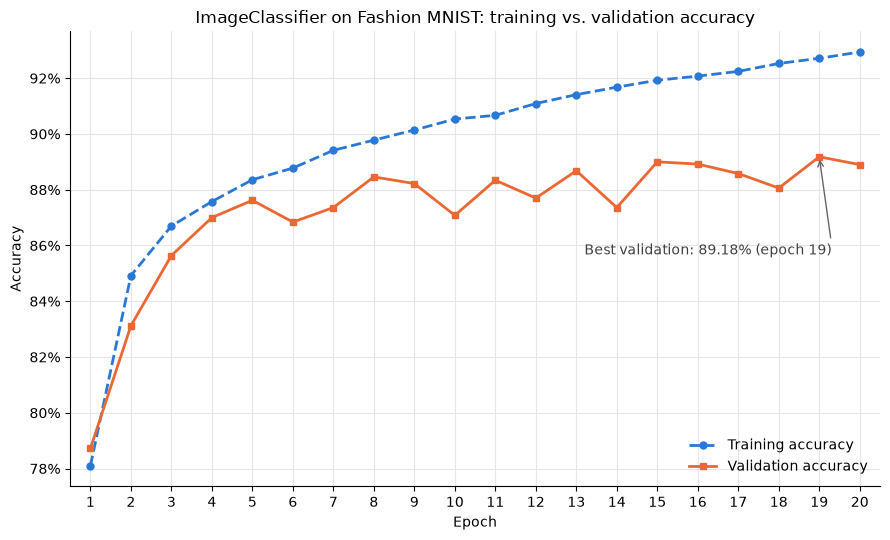

In [7]:
"""
CSCI E-89 Assignment 03, Problem 1 -- Step 7: Plot accuracy per epoch
Author: Levente Papp

Plots training and validation accuracy per epoch from the history saved by
step 6. The figure is saved to prob1/figures/accuracy.png and also shown.

Notebook cell 7. Run the cells in order (1-8) from a notebook in the
repo root; each cell uses names defined by the earlier cells.
"""

HISTORY_PATH = Path("prob1/outputs/history.json")
FIG_PATH = Path("prob1/figures/accuracy.png")

TRAIN_COLOR = "#2a78d6"  # blue
VALID_COLOR = "#eb6834"  # orange

if not HISTORY_PATH.exists():
    raise SystemExit(f"{HISTORY_PATH} not found -- run the step 6 cell (06_train.py) first.")
history = json.loads(HISTORY_PATH.read_text())

train_acc = np.array(history["train_metrics"])
valid_acc = np.array(history["valid_metrics"])
epochs = np.arange(1, len(train_acc) + 1)
best = valid_acc.argmax()

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(epochs, train_acc, "o--", color=TRAIN_COLOR, linewidth=2,
        markersize=5, label="Training accuracy")
ax.plot(epochs, valid_acc, "s-", color=VALID_COLOR, linewidth=2,
        markersize=5, label="Validation accuracy")

# Mark the best validation epoch
ax.annotate(f"Best validation: {valid_acc[best]:.2%} (epoch {epochs[best]})",
            xy=(epochs[best], valid_acc[best]),
            xytext=(epochs[best] + 0.3, valid_acc[best] - 0.035),
            ha="right", color="0.25",
            arrowprops=dict(arrowstyle="->", color="0.4", relpos=(1, 1)))

ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.set_title("ImageClassifier on Fashion MNIST: training vs. validation accuracy")
ax.set_xticks(epochs)
ax.set_xlim(0.5, epochs[-1] + 0.5)
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0, decimals=0))
ax.grid(color="0.9")
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
ax.legend(loc="lower right", frameon=False)
fig.tight_layout()

FIG_PATH.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(FIG_PATH, dpi=120)
print(f"Final training accuracy:   {train_acc[-1]:.4f}")
print(f"Final validation accuracy: {valid_acc[-1]:.4f}")
print(f"Gap at final epoch:        {train_acc[-1] - valid_acc[-1]:.4f}")
print(f"Saved plot to {FIG_PATH}")

# plt.show() only has an effect with an interactive backend (not on a headless machine)
if plt.get_backend().lower() != "agg":
    plt.show()

## Step 8: Evaluate
**Script:** `prob1/08_evaluate.py`

Test-set accuracy, then predicted vs. true classes, class probabilities, and top-4 predictions for 3 validation images.

In [8]:
"""
CSCI E-89 Assignment 03, Problem 1 -- Step 8: Evaluate the trained model
Author: Levente Papp

Loads the weights saved by step 6, reports test-set accuracy, then for the
first 3 validation images shows the predicted and true classes, the full
class probabilities, and the top-4 predictions.

Notebook cell 8. Run the cells in order (1-8) from a notebook in the
repo root; each cell uses names defined by the earlier cells.
"""

WEIGHTS_PATH = Path("prob1/outputs/model.pt")
N_SAMPLES = 3
TOP_K = 4

if not WEIGHTS_PATH.exists():
    raise SystemExit(f"{WEIGHTS_PATH} not found -- run the step 6 cell (06_train.py) first.")
model.load_state_dict(torch.load(WEIGHTS_PATH, map_location=device))
classes = train_and_valid_data.classes

# --- Test-set accuracy ---
test_acc = evaluate_tm(model, test_loader, accuracy).item()
valid_acc = evaluate_tm(model, valid_loader, accuracy).item()
print(f"Validation accuracy: {valid_acc:.4f}")
print(f"Test accuracy:       {test_acc:.4f}  ({len(test_data):,} images)")

# --- Predictions for 3 validation images ---
model.eval()
X_new, y_new = next(iter(valid_loader))  # valid_loader is not shuffled
X_new, y_new = X_new[:N_SAMPLES].to(device), y_new[:N_SAMPLES]
with torch.no_grad():
    y_pred_logits = model(X_new)
y_pred = y_pred_logits.argmax(dim=1).cpu()  # index of the largest logit

print(f"\nPredicted class indices: {y_pred.tolist()}")
print(f"True class indices:      {y_new.tolist()}")
print(f"Predicted classes: {[classes[i] for i in y_pred]}")
print(f"True classes:      {[classes[i] for i in y_new]}")
print(f"Correct: {(y_pred == y_new).sum().item()}/{N_SAMPLES}")

# Class probabilities (softmax over all 10 logits); move to CPU for printing
y_proba = F.softmax(y_pred_logits, dim=1).cpu()
print("\nClass probabilities:")
header = "".join(f"{name[:11]:>12s}" for name in classes)
print(f"{'':8s}{header}")
for i, row in enumerate(y_proba):
    print(f"Image {i + 1:<2d}" + "".join(f"{p:>12.3f}" for p in row))

# Top-4: softmax over only the 4 largest logits, as in the notebook
y_top_values, y_top_indices = torch.topk(y_pred_logits, k=TOP_K, dim=1)
y_top_probas = F.softmax(y_top_values, dim=1).cpu()
y_top_indices = y_top_indices.cpu()
print(f"\nTop-{TOP_K} probabilities (renormalized over the top {TOP_K}):")
print(y_top_probas.round(decimals=3))
print(f"Top-{TOP_K} class indices:")
print(y_top_indices)

print(f"\nTop-{TOP_K} predictions per image:")
for i in range(N_SAMPLES):
    ranked = ", ".join(f"{classes[j]} ({p:.3f})"
                       for j, p in zip(y_top_indices[i], y_top_probas[i]))
    print(f"Image {i + 1} (true: {classes[y_new[i]]}): {ranked}")

Validation accuracy: 0.8890
Test accuracy:       0.8851  (10,000 images)

Predicted class indices: [7, 4, 2]
True class indices:      [7, 4, 2]
Predicted classes: ['Sneaker', 'Coat', 'Pullover']
True classes:      ['Sneaker', 'Coat', 'Pullover']
Correct: 3/3

Class probabilities:
         T-shirt/top     Trouser    Pullover       Dress        Coat      Sandal       Shirt     Sneaker         Bag  Ankle boot
Image 1        0.000       0.000       0.000       0.000       0.000       0.000       0.000       0.962       0.000       0.038
Image 2        0.000       0.000       0.017       0.000       0.982       0.000       0.001       0.000       0.000       0.000
Image 3        0.000       0.000       0.685       0.000       0.243       0.000       0.072       0.000       0.000       0.000

Top-4 probabilities (renormalized over the top 4):
tensor([[0.9620, 0.0380, 0.0000, 0.0000],
        [0.9820, 0.0170, 0.0010, 0.0000],
        [0.6850, 0.2430, 0.0720, 0.0000]])
Top-4 class indices:
ten